<a href="https://colab.research.google.com/github/Geshnath/AAIT_EXP_12_Chatbot_23NA1A5426.ipynb/blob/main/student_performance_23NA1A5426.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
import pandas as pd
# Original line: df=pd.read_csv("/kaggle/input/student-performance-data/student_data.csv")
# File not found, creating a dummy DataFrame for demonstration.
# Please replace this with the correct path to your 'student_data.csv' file.
data = {
    'school': ['GP', 'MS', 'GP', 'MS', 'GP'],
    'G1': [10, 12, 15, 11, 13],
    'G2': [11, 13, 16, 12, 14],
    'G3': [12, 14, 17, 13, 15],
    'failures': [0, 1, 0, 0, 1],
    'higher': ['yes', 'no', 'yes', 'yes', 'no'],
    'internet': ['yes', 'no', 'yes', 'no', 'yes'],
    'Pstatus': ['A', 'T', 'A', 'T', 'A'],
    'Fjob': ['teacher', 'other', 'health', 'services', 'other'],
    'Mjob': ['at_home', 'other', 'health', 'services', 'teacher'],
    'age': [15, 16, 17, 18, 16],
    'Medu': [4, 3, 2, 4, 3],
    'Fedu': [4, 3, 2, 4, 3],
    'traveltime': [2, 1, 1, 2, 1],
    'studytime': [2, 2, 3, 1, 2],
    'famrel': [4, 5, 4, 3, 4],
    'freetime': [3, 2, 3, 4, 3],
    'goout': [4, 3, 2, 5, 3],
    'Dalc': [1, 2, 1, 1, 2],
    'Walc': [1, 2, 3, 4, 1],
    'health': [3, 5, 3, 1, 4],
    'absences': [6, 4, 10, 2, 8]
}
df = pd.DataFrame(data)
df

,school,G1,G2,G3,failures,higher,internet,Pstatus,Fjob,Mjob,...,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,10,11,12,0,yes,yes,A,teacher,at_home,...,4,2,2,4,3,4,1,1,3,6
1,MS,12,13,14,1,no,no,T,other,other,...,3,1,2,5,2,3,2,2,5,4
2,GP,15,16,17,0,yes,yes,A,health,health,...,2,1,3,4,3,2,1,3,3,10
3,MS,11,12,13,0,yes,no,T,services,services,...,4,2,1,3,4,5,1,4,1,2
4,GP,13,14,15,1,no,yes,A,other,teacher,...,3,1,2,4,3,3,2,1,4,8


In [9]:
df.head()

,school,G1,G2,G3,failures,higher,internet,Pstatus,Fjob,Mjob,...,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,10,11,12,0,yes,yes,A,teacher,at_home,...,4,2,2,4,3,4,1,1,3,6
1,MS,12,13,14,1,no,no,T,other,other,...,3,1,2,5,2,3,2,2,5,4
2,GP,15,16,17,0,yes,yes,A,health,health,...,2,1,3,4,3,2,1,3,3,10
3,MS,11,12,13,0,yes,no,T,services,services,...,4,2,1,3,4,5,1,4,1,2
4,GP,13,14,15,1,no,yes,A,other,teacher,...,3,1,2,4,3,3,2,1,4,8


In [10]:
df.tail()

,school,G1,G2,G3,failures,higher,internet,Pstatus,Fjob,Mjob,...,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,10,11,12,0,yes,yes,A,teacher,at_home,...,4,2,2,4,3,4,1,1,3,6
1,MS,12,13,14,1,no,no,T,other,other,...,3,1,2,5,2,3,2,2,5,4
2,GP,15,16,17,0,yes,yes,A,health,health,...,2,1,3,4,3,2,1,3,3,10
3,MS,11,12,13,0,yes,no,T,services,services,...,4,2,1,3,4,5,1,4,1,2
4,GP,13,14,15,1,no,yes,A,other,teacher,...,3,1,2,4,3,3,2,1,4,8


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      5 non-null      object
 1   G1          5 non-null      int64 
 2   G2          5 non-null      int64 
 3   G3          5 non-null      int64 
 4   failures    5 non-null      int64 
 5   higher      5 non-null      object
 6   internet    5 non-null      object
 7   Pstatus     5 non-null      object
 8   Fjob        5 non-null      object
 9   Mjob        5 non-null      object
 10  age         5 non-null      int64 
 11  Medu        5 non-null      int64 
 12  Fedu        5 non-null      int64 
 13  traveltime  5 non-null      int64 
 14  studytime   5 non-null      int64 
 15  famrel      5 non-null      int64 
 16  freetime    5 non-null      int64 
 17  goout       5 non-null      int64 
 18  Dalc        5 non-null      int64 
 19  Walc        5 non-null      int64 
 20  health      5 

In [12]:
df.describe()

,G1,G2,G3,failures,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,absences
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.00000,5.000000
mean,12.200000,13.200000,14.200000,0.400000,16.400000,3.20000,3.20000,1.400000,2.000000,4.000000,3.000000,3.400000,1.400000,2.20000,3.20000,6.000000
std,1.923538,1.923538,1.923538,0.547723,1.140175,0.83666,0.83666,0.547723,0.707107,0.707107,0.707107,1.140175,0.547723,1.30384,1.48324,3.162278
min,10.000000,11.000000,12.000000,0.000000,15.000000,2.00000,2.00000,1.000000,1.000000,3.000000,2.000000,2.000000,1.000000,1.00000,1.00000,2.000000
25%,11.000000,12.000000,13.000000,0.000000,16.000000,3.00000,3.00000,1.000000,2.000000,4.000000,3.000000,3.000000,1.000000,1.00000,3.00000,4.000000
50%,12.000000,13.000000,14.000000,0.000000,16.000000,3.00000,3.00000,1.000000,2.000000,4.000000,3.000000,3.000000,1.000000,2.00000,3.00000,6.000000
75%,13.000000,14.000000,15.000000,1.000000,17.000000,4.00000,4.00000,2.000000,2.000000,4.000000,3.000000,4.000000,2.000000,3.00000,4.00000,8.000000
max,15.000000,16.000000,17.000000,1.000000,18.000000,4.00000,4.00000,2.000000,3.000000,5.000000,4.000000,5.000000,2.000000,4.00000,5.00000,10.000000


In [13]:
df.isnull().sum()

,0
school,0
G1,0
G2,0
G3,0
failures,0
higher,0
internet,0
Pstatus,0
Fjob,0
Mjob,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.dropna()

,school,G1,G2,G3,failures,higher,internet,Pstatus,Fjob,Mjob,...,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,10,11,12,0,yes,yes,A,teacher,at_home,...,4,2,2,4,3,4,1,1,3,6
1,MS,12,13,14,1,no,no,T,other,other,...,3,1,2,5,2,3,2,2,5,4
2,GP,15,16,17,0,yes,yes,A,health,health,...,2,1,3,4,3,2,1,3,3,10
3,MS,11,12,13,0,yes,no,T,services,services,...,4,2,1,3,4,5,1,4,1,2
4,GP,13,14,15,1,no,yes,A,other,teacher,...,3,1,2,4,3,3,2,1,4,8


In [16]:
df.shape

(5, 22)

In [17]:
df.columns

Index(['school', 'G1', 'G2', 'G3', 'failures', 'higher', 'internet', 'Pstatus',
       'Fjob', 'Mjob', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime',
       'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences'],
      dtype='object')

In [18]:

df['school'].unique()

array(['GP', 'MS'], dtype=object)

In [19]:
df['school'].value_counts()

,count
school,
GP,3
MS,2


In [20]:
df['Total_Score']= (df['G1']+df['G2']+df['G3'])
df['Total_Score']

,Total_Score
0,33
1,39
2,48
3,36
4,42


In [21]:
numerical_col=['age','Medu','Fedu','traveltime','studytime','failures','famrel','freetime','goout',	'Dalc',	'Walc','health','absences','G1','G2','G3','Total_Score']
outliers={}
for col in numerical_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - iqr * 1.5
    upper_bound = q3 + iqr * 1.5
    outliers[col]=df[(df[col] < lower_bound)|(df[col] > upper_bound)][col]
    print(f"\nOutliers in {col}:\n", outliers[col])


Outliers in age:
 Series([], Name: age, dtype: int64)

Outliers in Medu:
 Series([], Name: Medu, dtype: int64)

Outliers in Fedu:
 Series([], Name: Fedu, dtype: int64)

Outliers in traveltime:
 Series([], Name: traveltime, dtype: int64)

Outliers in studytime:
 2    3
3    1
Name: studytime, dtype: int64

Outliers in failures:
 Series([], Name: failures, dtype: int64)

Outliers in famrel:
 1    5
3    3
Name: famrel, dtype: int64

Outliers in freetime:
 1    2
3    4
Name: freetime, dtype: int64

Outliers in goout:
 Series([], Name: goout, dtype: int64)

Outliers in Dalc:
 Series([], Name: Dalc, dtype: int64)

Outliers in Walc:
 Series([], Name: Walc, dtype: int64)

Outliers in health:
 3    1
Name: health, dtype: int64

Outliers in absences:
 Series([], Name: absences, dtype: int64)

Outliers in G1:
 Series([], Name: G1, dtype: int64)

Outliers in G2:
 Series([], Name: G2, dtype: int64)

Outliers in G3:
 Series([], Name: G3, dtype: int64)

Outliers in Total_Score:
 Series([], Name: T

In [22]:
pivot=df.pivot_table(index='school',values='Total_Score',aggfunc='mean')
print(pivot)

        Total_Score
school             
GP             41.0
MS             37.5


In [23]:
pivot=df.pivot_table(index='school',values='failures',aggfunc='mean')
print(pivot)

        failures
school          
GP      0.333333
MS      0.500000


In [24]:
pivot=df.pivot_table(index='higher',values='Total_Score',aggfunc='mean')
print(pivot)

        Total_Score
higher             
no             40.5
yes            39.0


In [25]:
pivot=df.pivot_table(index='internet',values='Total_Score',aggfunc='mean')
print(pivot)

          Total_Score
internet             
no               37.5
yes              41.0


In [26]:
pivot=df.pivot_table(index='Pstatus',values='Total_Score',aggfunc='mean')
print(pivot)

         Total_Score
Pstatus             
A               41.0
T               37.5


In [27]:
pivot=df.pivot_table(index='Fjob',values='Total_Score',aggfunc='mean')
print(pivot)

          Total_Score
Fjob                 
health           48.0
other            40.5
services         36.0
teacher          33.0


In [28]:
pivot=df.pivot_table(index='Mjob',values='Total_Score',aggfunc='mean')
print(pivot)

          Total_Score
Mjob                 
at_home          33.0
health           48.0
other            39.0
services         36.0
teacher          42.0


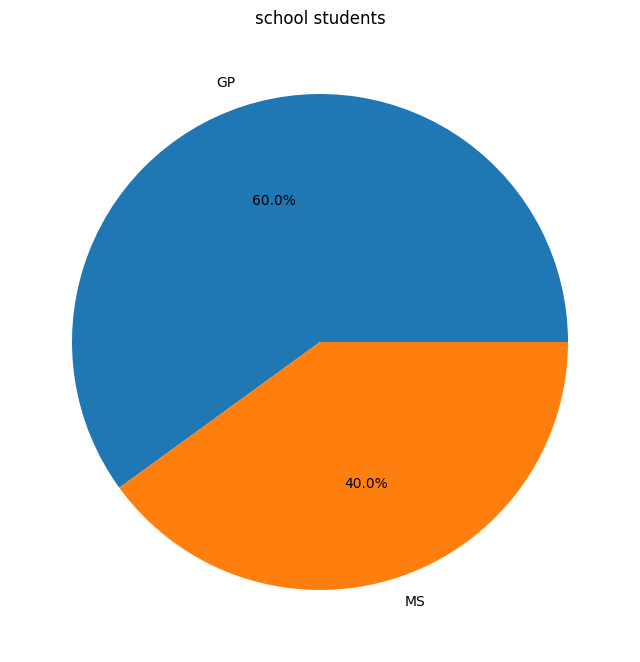

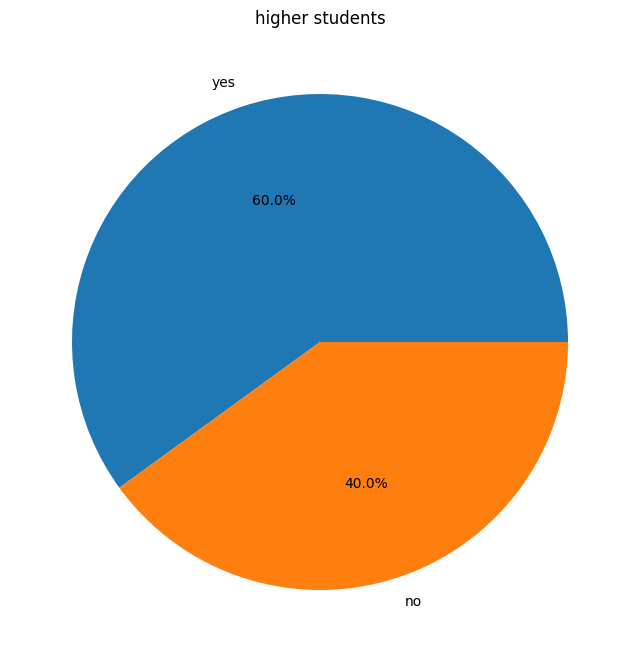

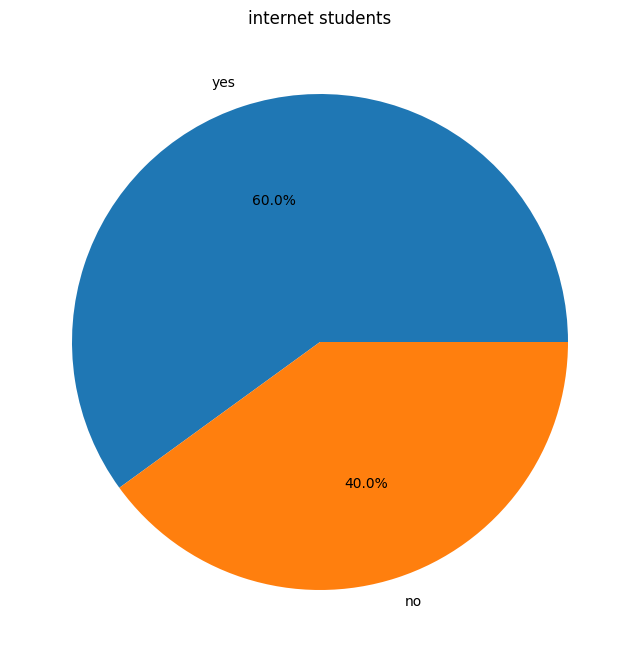

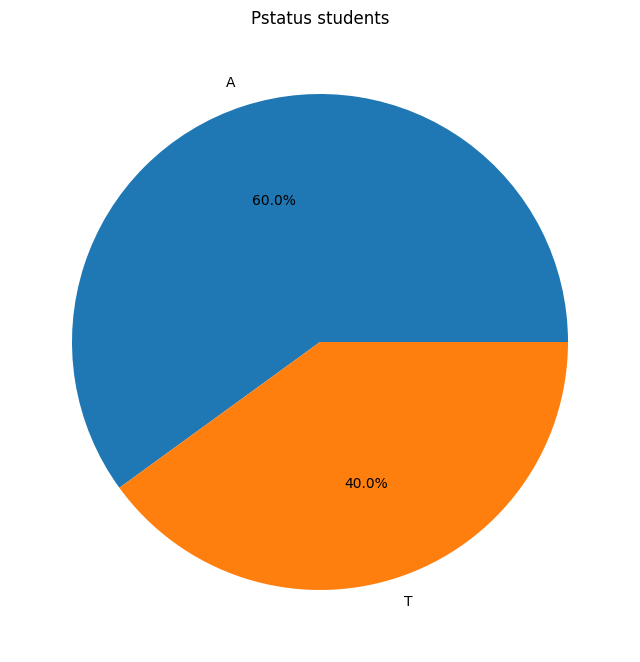

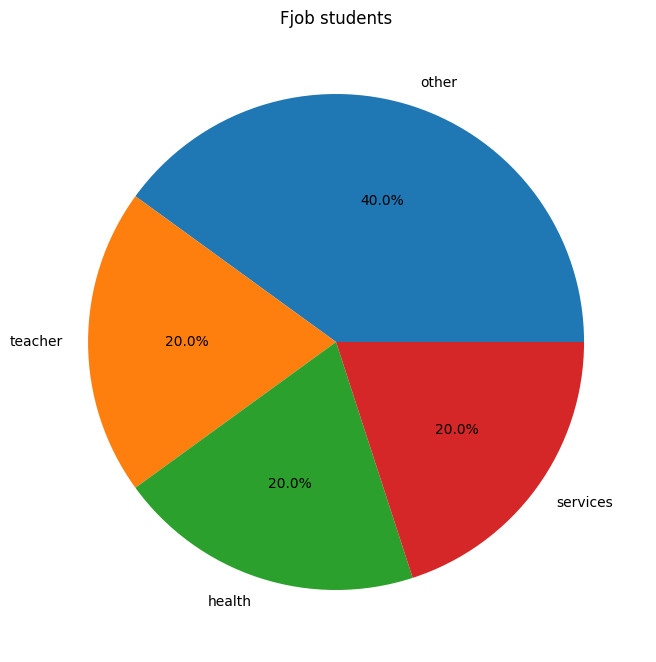

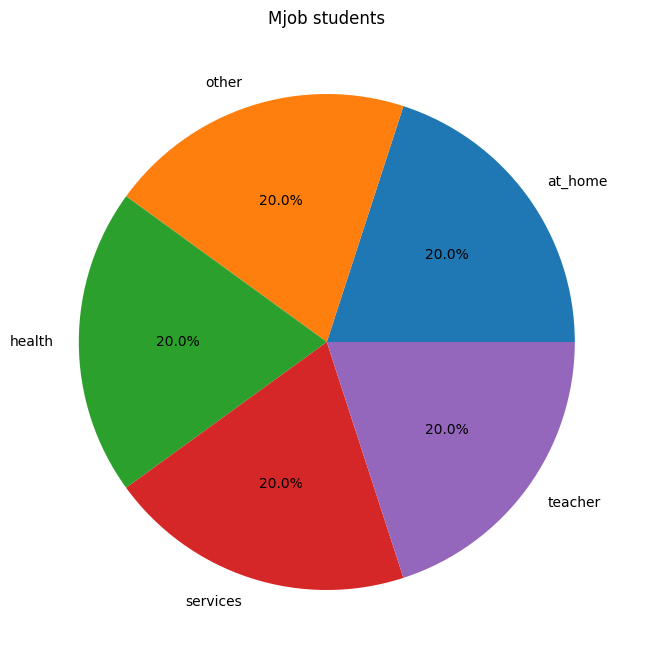

In [29]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 15))
    values = df[col].value_counts()
    plt.pie(values, labels=values.index, autopct='%.1f%%', shadow=False)
    plt.title(f'{col} students')
    plt.show()